In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/electric_vehicle_analytics.csv')

In [ ]:
df.head()

,Vehicle_ID,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
0,1,Nissan,Leaf,2021,Asia,SUV,101.7,75.5,565,153.6,...,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
1,2,Nissan,Leaf,2020,Australia,Sedan,30.1,99.8,157,157.2,...,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
2,3,Hyundai,Kona Electric,2021,North America,SUV,118.5,84.0,677,173.6,...,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
3,4,Audi,Q4 e-tron,2022,Europe,Hatchback,33.1,97.3,149,169.3,...,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
4,5,Tesla,Model 3,2022,Australia,Truck,81.3,85.6,481,212.8,...,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033


In [ ]:
df.shape

(3000, 25)

In [ ]:
df.columns

Index(['Vehicle_ID', 'Make', 'Model', 'Year', 'Region', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
       'Charging_Power_kW', 'Charging_Time_hr', 'Charge_Cycles',
       'Energy_Consumption_kWh_per_100km', 'Mileage_km', 'Avg_Speed_kmh',
       'Max_Speed_kmh', 'Acceleration_0_100_kmh_sec', 'Temperature_C',
       'Usage_Type', 'CO2_Saved_tons', 'Maintenance_Cost_USD',
       'Insurance_Cost_USD', 'Electricity_Cost_USD_per_kWh',
       'Monthly_Charging_Cost_USD', 'Resale_Value_USD'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Make                              3000 non-null   object 
 2   Model                             3000 non-null   object 
 3   Year                              3000 non-null   int64  
 4   Region                            3000 non-null   object 
 5   Vehicle_Type                      3000 non-null   object 
 6   Battery_Capacity_kWh              3000 non-null   float64
 7   Battery_Health_%                  3000 non-null   float64
 8   Range_km                          3000 non-null   int64  
 9   Charging_Power_kW                 3000 non-null   float64
 10  Charging_Time_hr                  3000 non-null   float64
 11  Charge_Cycles                     3000 non-null   int64  
 12  Energy

In [ ]:
df.describe()

,Vehicle_ID,Year,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,Charge_Cycles,Energy_Consumption_kWh_per_100km,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,2019.499667,74.810100,85.030000,374.414667,129.301000,1.203570,1107.009667,18.589740,125209.685667,65.674067,190.678333,6.707073,14.794133,15.025163,1104.199000,1495.469333,0.216467,418.814683,22257.038000
std,866.169729,2.848047,25.734079,8.589526,137.184112,68.742745,1.421866,510.834590,3.767421,70465.774772,20.305364,35.184232,1.880355,14.407087,8.455850,521.530356,585.919978,0.078383,312.389226,5594.979382
min,1.000000,2015.000000,30.000000,70.000000,121.000000,11.100000,0.140000,200.000000,12.000000,5046.000000,30.000000,130.000000,3.500000,-10.000000,0.610000,200.000000,500.000000,0.080000,7.990000,8506.000000
25%,750.750000,2017.000000,53.000000,77.775000,260.000000,70.900000,0.460000,674.750000,15.320000,65140.500000,48.000000,159.000000,5.080000,2.400000,7.817500,652.000000,984.750000,0.150000,175.485000,17813.000000
50%,1500.500000,2020.000000,74.850000,85.250000,371.000000,126.700000,0.720000,1116.000000,18.700000,125965.000000,65.600000,191.500000,6.720000,14.550000,15.115000,1109.000000,1496.000000,0.220000,347.285000,22154.000000
75%,2250.250000,2022.000000,96.900000,92.300000,476.250000,187.975000,1.292500,1535.250000,21.830000,184764.750000,83.525000,222.000000,8.310000,27.500000,22.170000,1569.000000,2019.250000,0.280000,595.152500,26732.750000
max,3000.000000,2024.000000,120.000000,100.000000,713.000000,250.000000,12.140000,1997.000000,24.990000,249987.000000,100.000000,249.000000,10.000000,40.000000,30.000000,1999.000000,2498.000000,0.350000,1643.700000,35521.000000


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.rename(columns={'Mileage_km':'Total_Distance_Covered_km'})


In [ ]:
df=df.rename(columns={'Make':'Company'})


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Outlier Detection using IQR Method:")
for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    if not outliers.empty:
        print(f"\nColumn: {column}")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  Number of outliers: {len(outliers)}")
        print("  Outlier values (first 5 if many):\n", outliers[[column]].head())
    else:
        print(f"\nColumn: {column}: No outliers detected.")

Outlier Detection using IQR Method:

Column: Vehicle_ID: No outliers detected.

Column: Year: No outliers detected.

Column: Battery_Capacity_kWh: No outliers detected.

Column: Battery_Health_%: No outliers detected.

Column: Range_km: No outliers detected.

Column: Charging_Power_kW: No outliers detected.

Column: Charging_Time_hr
  Q1: 0.46, Q3: 1.29, IQR: 0.83
  Lower Bound: -0.79, Upper Bound: 2.54
  Number of outliers: 309
  Outlier values (first 5 if many):
     Charging_Time_hr
5               6.31
15              4.65
19              3.91
22              4.44
23              3.38

Column: Charge_Cycles: No outliers detected.

Column: Energy_Consumption_kWh_per_100km: No outliers detected.

Column: Total_Distance_Covered_km: No outliers detected.

Column: Avg_Speed_kmh: No outliers detected.

Column: Max_Speed_kmh: No outliers detected.

Column: Acceleration_0_100_kmh_sec: No outliers detected.

Column: Temperature_C: No outliers detected.

Column: CO2_Saved_tons: No outliers d

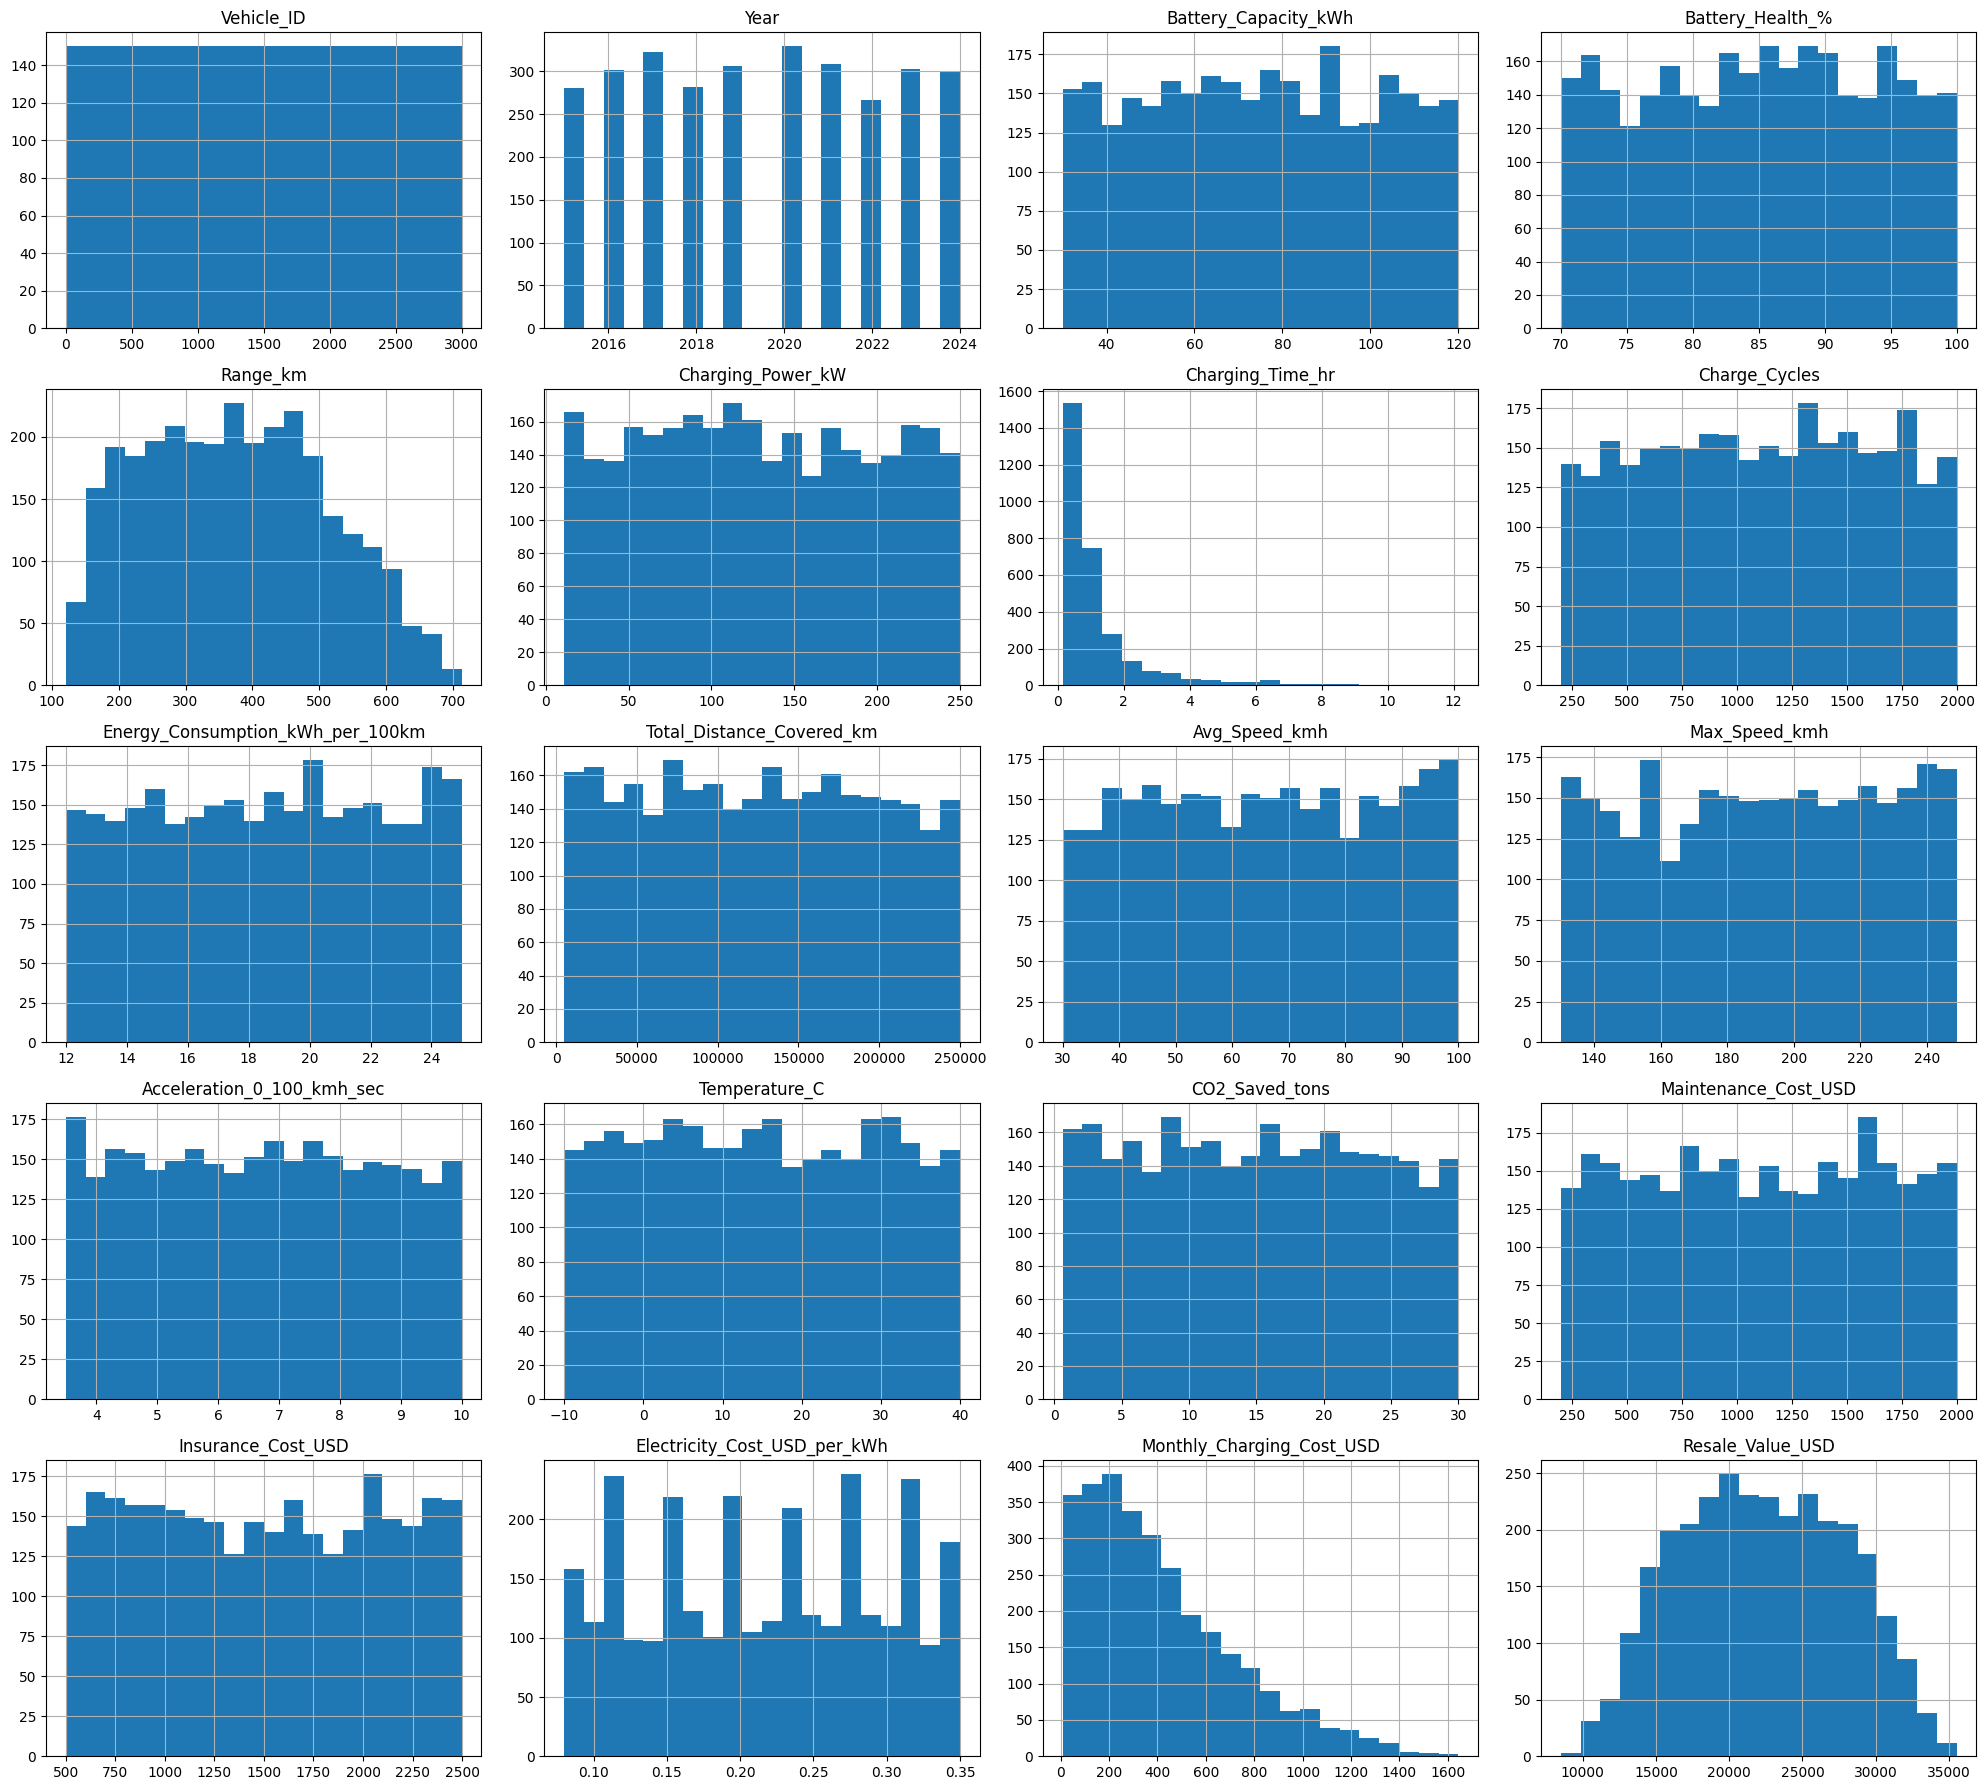

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(20,18), bins=20)
plt.tight_layout()
plt.show()

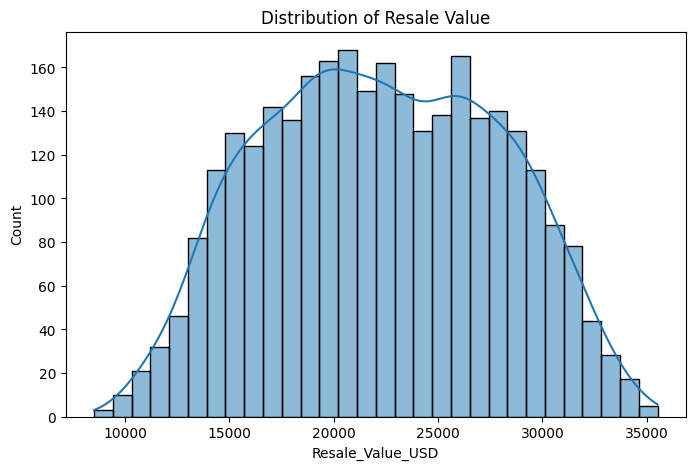

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Resale_Value_USD'], bins=30, kde=True)
plt.title("Distribution of Resale Value")
plt.show()

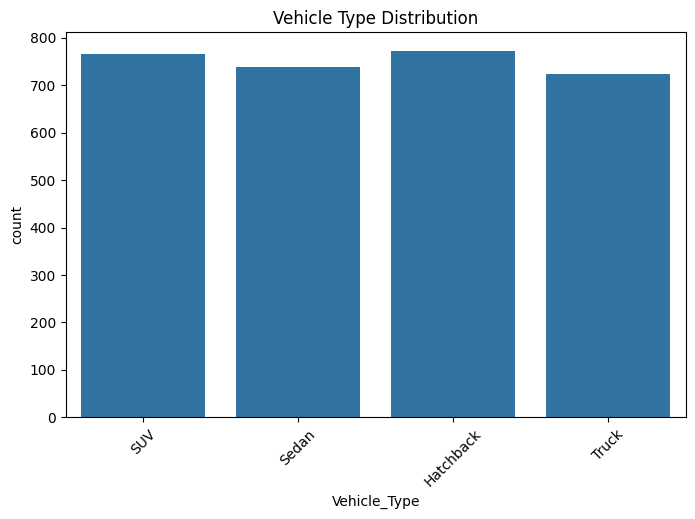

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Vehicle_Type')
plt.title("Vehicle Type Distribution")
plt.xticks(rotation=45)
plt.show()

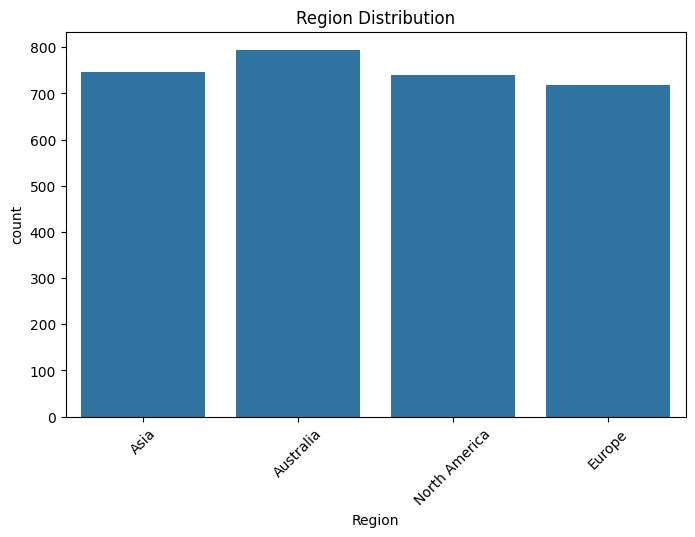

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Region')
plt.title("Region Distribution")
plt.xticks(rotation=45)
plt.show()

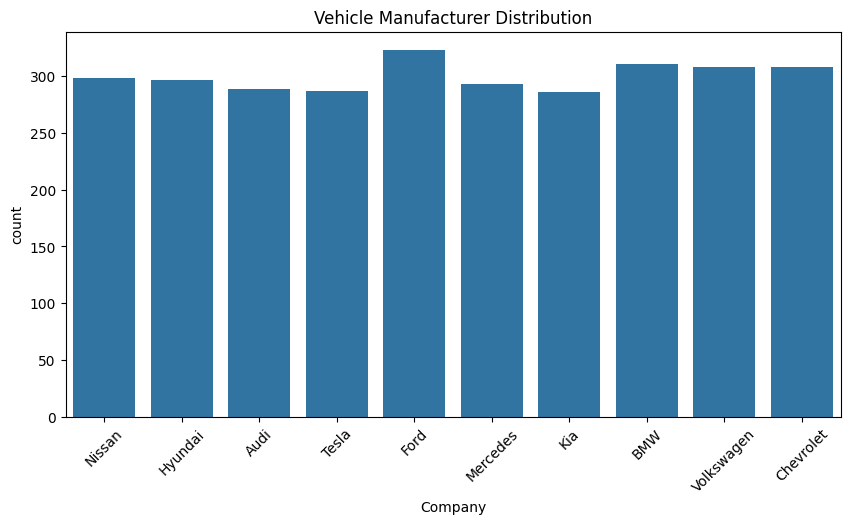

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Company')
plt.xticks(rotation=45)
plt.title("Vehicle Manufacturer Distribution")
plt.show()

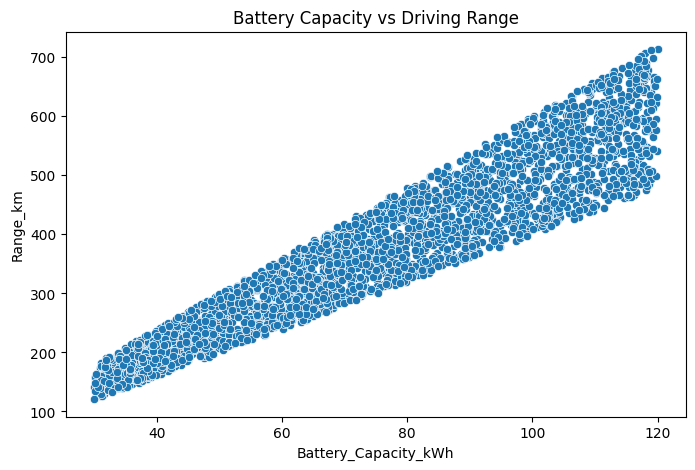

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Battery_Capacity_kWh',
                y='Range_km')
plt.title("Battery Capacity vs Driving Range")
plt.show()

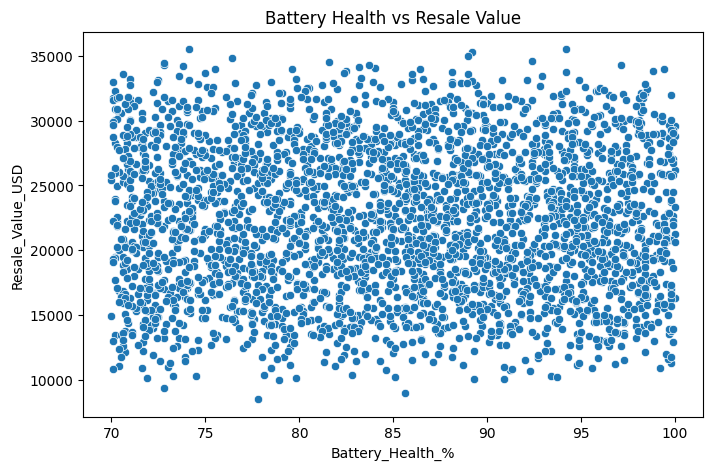

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Battery_Health_%',
                y='Resale_Value_USD')
plt.title("Battery Health vs Resale Value")
plt.show()

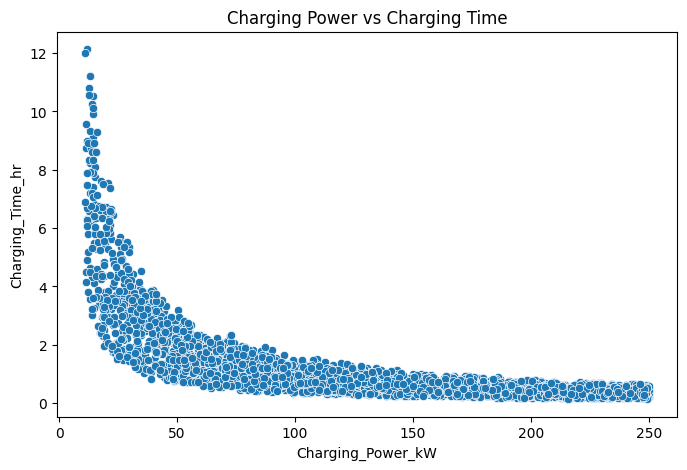

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Charging_Power_kW',
                y='Charging_Time_hr')
plt.title("Charging Power vs Charging Time")
plt.show()

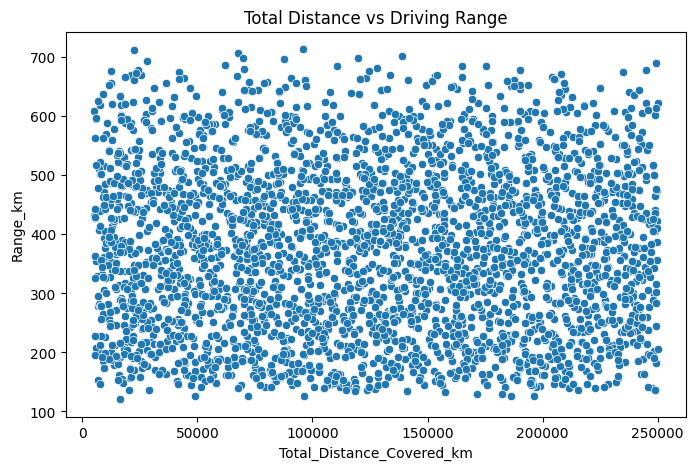

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Total_Distance_Covered_km', y='Range_km')
plt.title("Total Distance vs Driving Range")
plt.show()

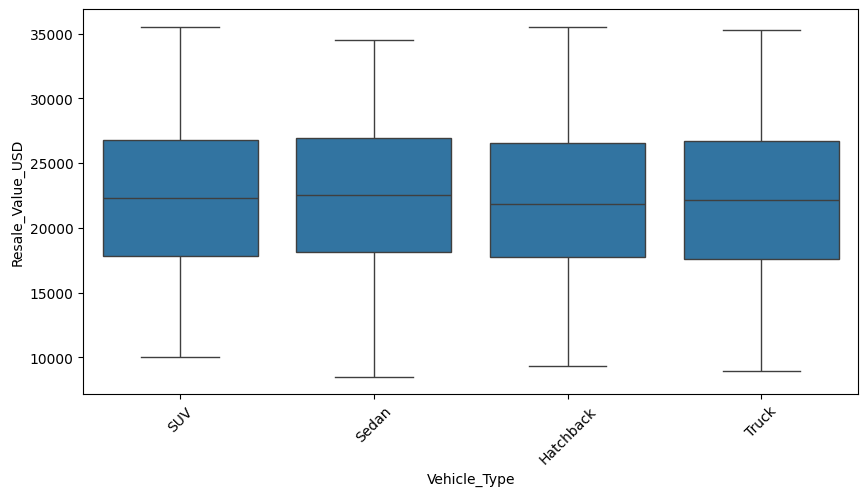

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
            x='Vehicle_Type',
            y='Resale_Value_USD')
plt.xticks(rotation=45)
plt.show()

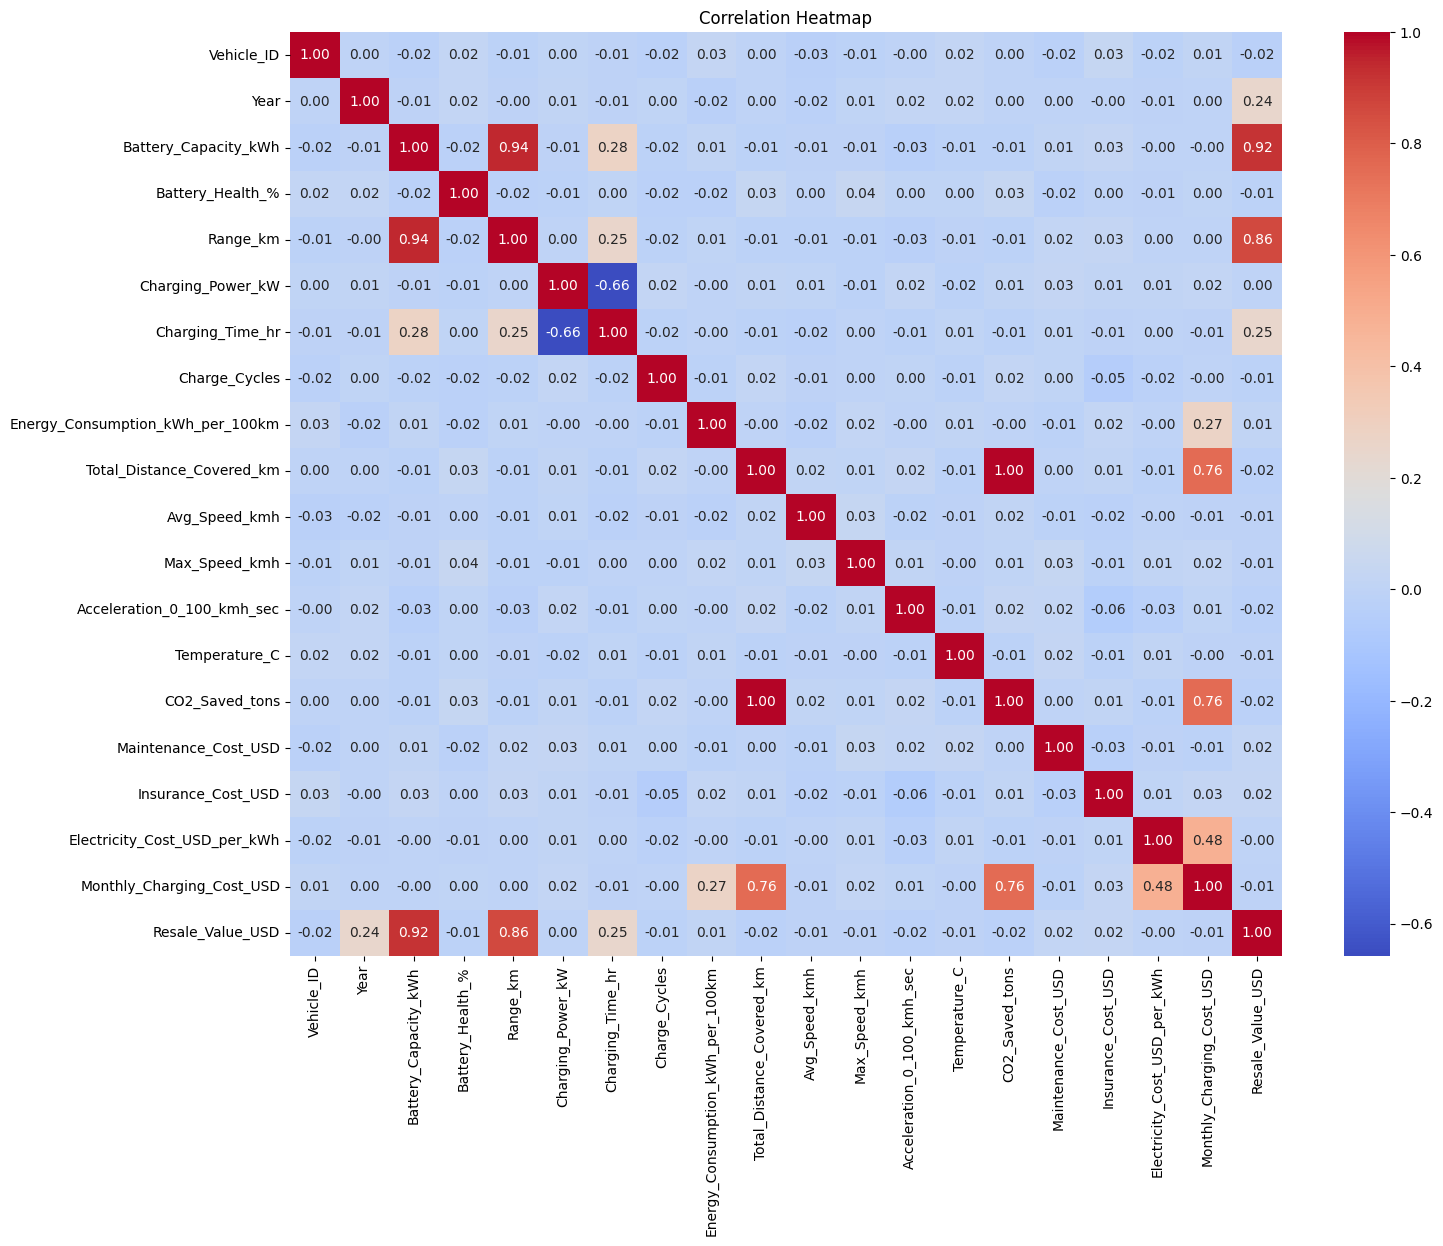

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.drop('Vehicle_ID', axis=1)

,Company,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
0,Nissan,Leaf,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
1,Nissan,Leaf,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
2,Hyundai,Kona Electric,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
3,Audi,Q4 e-tron,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
4,Tesla,Model 3,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Mercedes,EQS,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2996,Ford,Mustang Mach-E,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2997,Kia,Niro EV,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286
2998,Mercedes,EQC,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,185,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Company', 'Model', 'Region', 'Vehicle_Type', 'Usage_Type']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Vehicle_ID,Company,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
0,1,7,11,2021,0,1,101.7,75.5,565,153.6,...,233,8.10,-9.0,2,14.13,969,843,0.30,375.55,26483
1,2,7,11,2020,1,2,30.1,99.8,157,157.2,...,221,9.83,1.6,2,19.41,1157,1186,0.25,532.02,11287
2,3,4,10,2021,3,1,118.5,84.0,677,173.6,...,138,3.60,1.5,1,29.39,291,1890,0.26,1291.68,34023
3,4,0,18,2022,2,0,33.1,97.3,149,169.3,...,192,8.97,12.5,1,6.96,401,2481,0.33,234.44,14398
4,5,8,12,2022,1,3,81.3,85.6,481,212.8,...,189,7.03,-3.0,0,2.06,214,2336,0.10,32.61,23033


In [ ]:
X = df.drop('Resale_Value_USD', axis=1)
y = df['Resale_Value_USD']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

mse_lr = round(mean_squared_error(y_test, y_pred_lr),2)
r2_lr = round(r2_score(y_test, y_pred_lr),2)
mae_lr = round(mean_absolute_error(y_test, y_pred_lr),2)
rmse_lr = round(root_mean_squared_error(y_test, y_pred_lr),2)

print("Linear Regression Test Data Metrics:")
print(f"MSE: {mse_lr}")
print(f"R²: {r2_lr}")
print(f"MAE: {mae_lr}")
print(f"RMSE: {rmse_lr}")

Linear Regression Test Data Metrics:
MSE: 3032843.57
R²: 0.9
MAE: 1510.9
RMSE: 1741.51


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

# Predictions on training data
y_train_pred = lr.predict(X_train)

# Calculate training metrics
mse_train = round(mean_squared_error(y_train, y_train_pred), 2)
r2_train = round(r2_score(y_train, y_train_pred), 2)
mae_train = round(mean_absolute_error(y_train, y_train_pred), 2)
rmse_train = round(root_mean_squared_error(y_train, y_train_pred), 2)

# Display results
print("Linear Regression Training Metrics:")
print(f"MSE: {mse_train}")
print(f"R²: {r2_train}")
print(f"MAE: {mae_train}")
print(f"RMSE: {rmse_train}")

Linear Regression Training Metrics:
MSE: 3095174.77
R²: 0.9
MAE: 1535.8
RMSE: 1759.31


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Test Metrics")
print("MSE:", round(mean_squared_error(y_test, y_pred_dt),2))
print("R²:", round(r2_score(y_test, y_pred_dt),2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_dt),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_dt)),2))

Decision Tree Test Metrics
MSE: 3541900.87
R²: 0.88
MAE: 1582.7
RMSE: 1881.99


In [ ]:
y_pred_dt = dt.predict(X_train)

print("Decision Tree Training Metrics")
print("MSE:", round(mean_squared_error(y_train, y_pred_dt),2))
print("R²:", round(r2_score(y_train, y_pred_dt),2))
print("MAE:", round(mean_absolute_error(y_train, y_pred_dt),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train, y_pred_dt)),2))

Decision Tree Training Metrics
MSE: 3274403.9
R²: 0.9
MAE: 1528.59
RMSE: 1809.53


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MSE:", round(mean_squared_error(y_test, y_pred_rf),2))
print("R²:", round(r2_score(y_test, y_pred_rf),2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_rf),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)),2))

Random Forest
MSE: 3248687.72
R²: 0.89
MAE: 1527.91
RMSE: 1802.41


In [ ]:
y_pred_rf = rf.predict(X_train)

print("Random Forest")
print("MSE:", round(mean_squared_error(y_train, y_pred_rf),2))
print("R²:", round(r2_score(y_train, y_pred_rf),2))
print("MAE:", round(mean_absolute_error(y_train, y_pred_rf),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train, y_pred_rf)),2))

Random Forest
MSE: 1170190.06
R²: 0.96
MAE: 914.57
RMSE: 1081.75


In [ ]:
y_pred_dt_test = dt.predict(X_test)
y_pred_rf_test = rf.predict(X_test)

metrics_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lr, round(mean_squared_error(y_test, y_pred_dt_test), 2), round(mean_squared_error(y_test, y_pred_rf_test), 2)],
    'R2': [r2_lr, round(r2_score(y_test, y_pred_dt_test), 2), round(r2_score(y_test, y_pred_rf_test), 2)],
    'MAE': [mae_lr, round(mean_absolute_error(y_test, y_pred_dt_test), 2), round(mean_absolute_error(y_test, y_pred_rf_test), 2)],
    'RMSE': [rmse_lr, round(np.sqrt(mean_squared_error(y_test, y_pred_dt_test)), 2), round(np.sqrt(mean_squared_error(y_test, y_pred_rf_test)), 2)]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

               Model         MSE    R2      MAE     RMSE
0  Linear Regression  3032843.57  0.90  1510.90  1741.51
1      Decision Tree  3541900.87  0.88  1582.70  1881.99
2      Random Forest  3248687.72  0.89  1527.91  1802.41


In [ ]:
# Calculate training metrics for Decision Tree
mse_dt_train = round(mean_squared_error(y_train, dt.predict(X_train)), 2)
r2_dt_train = round(r2_score(y_train, dt.predict(X_train)), 2)
mae_dt_train = round(mean_absolute_error(y_train, dt.predict(X_train)), 2)
rmse_dt_train = round(np.sqrt(mean_squared_error(y_train, dt.predict(X_train))), 2)

# Calculate training metrics for Random Forest
mse_rf_train = round(mean_squared_error(y_train, rf.predict(X_train)), 2)
r2_rf_train = round(r2_score(y_train, rf.predict(X_train)), 2)
mae_rf_train = round(mean_absolute_error(y_train, rf.predict(X_train)), 2)
rmse_rf_train = round(np.sqrt(mean_squared_error(y_train, rf.predict(X_train))), 2)

training_metrics_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE_Train': [mse_train, mse_dt_train, mse_rf_train],
    'R2_Train': [r2_train, r2_dt_train, r2_rf_train],
    'MAE_Train': [mae_train, mae_dt_train, mae_rf_train],
    'RMSE_Train': [rmse_train, rmse_dt_train, rmse_rf_train]
}

training_metrics_df = pd.DataFrame(training_metrics_data)
print(training_metrics_df)

               Model   MSE_Train  R2_Train  MAE_Train  RMSE_Train
0  Linear Regression  3095174.77      0.90    1535.80     1759.31
1      Decision Tree  3274403.90      0.90    1528.59     1809.53
2      Random Forest  1170190.06      0.96     914.57     1081.75


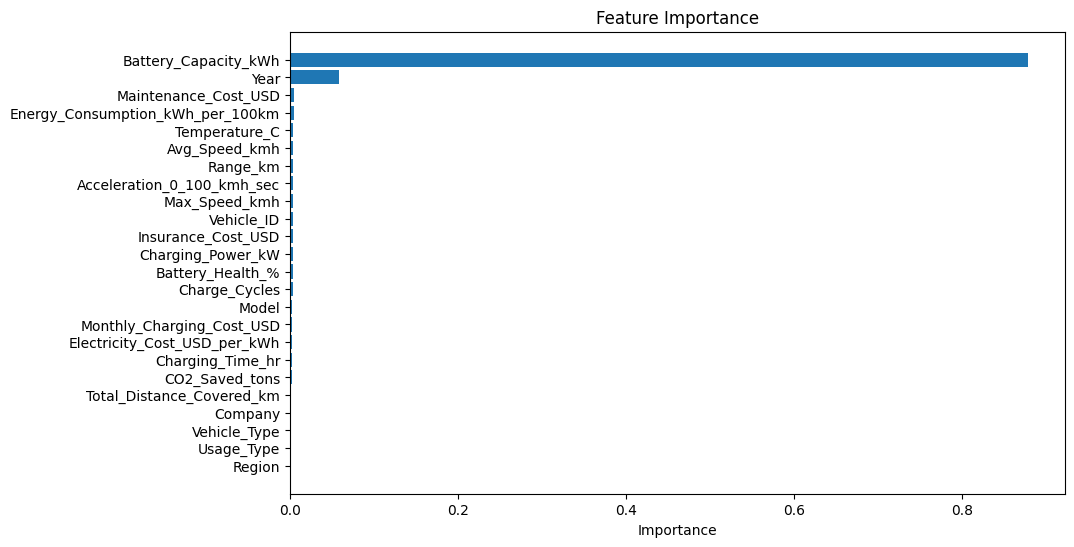

In [ ]:
feature_importances = rf.feature_importances_
importance = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

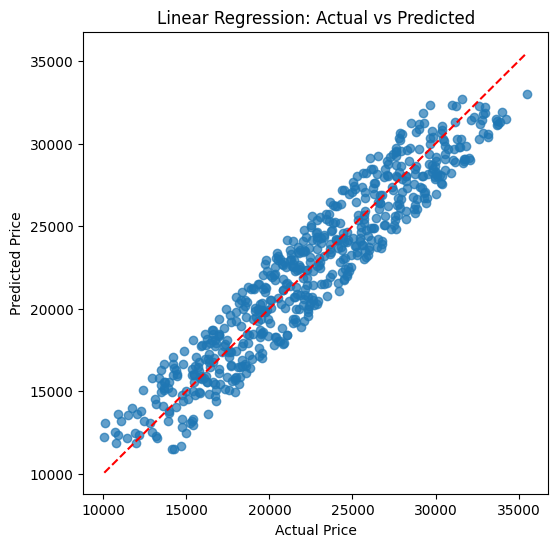

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

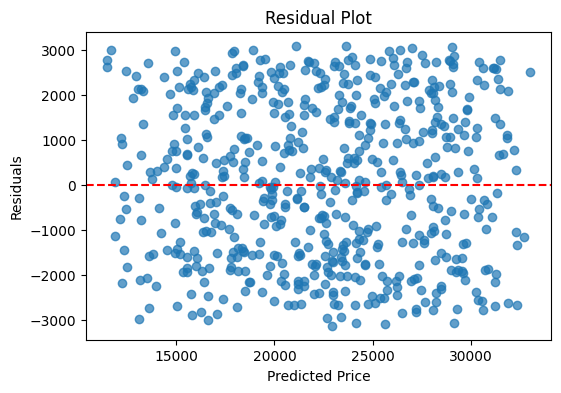

In [ ]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()